# 05 — Análisis Final e Integración

**Objetivo:** Integrar todos los resultados del proyecto (supervisado + no supervisado), seleccionar los mejores modelos y extraer conclusiones finales.

**Modelos evaluados:**
- Clasificación: 7 modelos → LogisticRegression, DecisionTree, RandomForest, GradientBoosting, SVM, XGBoost, StackingEnsemble
- Regresión: 6 modelos → LinearRegression, Ridge, Lasso, DecisionTreeReg, RandomForestReg, XGBoostRegressor
- No supervisado: PCA (2 componentes) + K-Means (k=3)

---

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             r2_score, mean_absolute_error, mean_squared_error,
                             roc_curve, auc, confusion_matrix)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor,
                               StackingClassifier)
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/plots', exist_ok=True)

print('✅ Librerías importadas')

✅ Librerías importadas


In [2]:
df = pd.read_csv('../data/04_feature/dataset_ml_preparado.csv', encoding='latin-1')
EXCLUDE = ['id_empleado', 'nombre', 'rut', 'departamento', 'cargo',
            'fecha_ingreso', 'salario', 'tipo_contrato', 'jornada',
            'alto_desempeno', 'avg_desempeno', 'score_global']
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]
X = df[feature_cols].copy()
y_clf = df['alto_desempeno'].astype(int)
y_reg = df['avg_desempeno'].copy()
X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Features ({len(feature_cols)}): {feature_cols}')

Train: 204  |  Test: 51
Features (14): ['avg_tecnicas', 'avg_blandas', 'total_dias_ausencia', 'total_horas_capacitacion', 'antiguedad_anos', 'total_dias_ausencia_norm', 'total_horas_capacitacion_norm', 'antiguedad_anos_norm', 'departamento_encoded', 'cargo_encoded', 'tipo_contrato_encoded', 'jornada_encoded', 'ratio_cap_antiguedad', 'tasa_ausencia']


## 1. Carga y Preparación del Dataset

## 2. Entrenamiento de Todos los Modelos

In [3]:
clf_models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'DecisionTree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'RandomForest':       RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1),
    'SVM':                SVC(random_state=42, probability=True, class_weight='balanced'),
    'XGBoost':            XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', verbosity=0),
    'StackingEnsemble':   StackingClassifier(
                              estimators=[
                                  ('xgb', XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss', verbosity=0)),
                                  ('gb',  GradientBoostingClassifier(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=4)),
                                  ('svm', SVC(random_state=42, probability=True, class_weight='balanced')),
                              ],
                              final_estimator=LogisticRegression(random_state=42),
                              cv=5
                          ),
}

reg_models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(random_state=42),
    'Lasso':            Lasso(random_state=42),
    'DecisionTreeReg':  DecisionTreeRegressor(random_state=42),
    'RandomForestReg':  RandomForestRegressor(random_state=42, n_estimators=100),
    'XGBoostRegressor': XGBRegressor(random_state=42, n_estimators=100, eval_metric='rmse', verbosity=0),
}

clf_pipes, clf_results = {}, []
for name, model in clf_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    pipe.fit(X_train, y_clf_train)
    clf_pipes[name] = pipe
    y_pred = pipe.predict(X_test)
    cv = cross_val_score(pipe, X, y_clf, cv=5, scoring='f1', n_jobs=-1)
    clf_results.append({
        'Modelo':      name,
        'CV_F1':       round(cv.mean(), 4),
        'Test_F1':     round(f1_score(y_clf_test, y_pred), 4),
        'Test_Acc':    round(accuracy_score(y_clf_test, y_pred), 4),
        'Test_Prec':   round(precision_score(y_clf_test, y_pred, zero_division=0), 4),
        'Test_Recall': round(recall_score(y_clf_test, y_pred), 4),
    })
    print(f'✅ {name:20s} — CV F1: {cv.mean():.4f}  |  Test F1: {f1_score(y_clf_test, y_pred):.4f}')

reg_pipes, reg_results = {}, []
for name, model in reg_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_train, y_reg_train)
    reg_pipes[name] = pipe
    y_pred = pipe.predict(X_test)
    cv = cross_val_score(pipe, X, y_reg, cv=5, scoring='r2', n_jobs=-1)
    reg_results.append({
        'Modelo':    name,
        'CV_R2':     round(cv.mean(), 4),
        'Test_R2':   round(r2_score(y_reg_test, y_pred), 4),
        'Test_MAE':  round(mean_absolute_error(y_reg_test, y_pred), 4),
        'Test_RMSE': round(np.sqrt(mean_squared_error(y_reg_test, y_pred)), 4),
    })
    print(f'✅ {name:20s} — CV R2: {cv.mean():.4f}  |  Test R2: {r2_score(y_reg_test, y_pred):.4f}')

df_clf = pd.DataFrame(clf_results).sort_values('Test_F1', ascending=False)
df_reg = pd.DataFrame(reg_results).sort_values('Test_R2', ascending=False)
print('\n✅ Entrenamiento completo')

✅ LogisticRegression   — CV F1: 0.7572  |  Test F1: 0.7547
✅ DecisionTree         — CV F1: 0.6881  |  Test F1: 0.6667
✅ RandomForest         — CV F1: 0.7092  |  Test F1: 0.8148
✅ GradientBoosting     — CV F1: 0.6853  |  Test F1: 0.7636
✅ SVM                  — CV F1: 0.7332  |  Test F1: 0.7692
✅ XGBoost              — CV F1: 0.7210  |  Test F1: 0.8214
✅ StackingEnsemble     — CV F1: 0.7182  |  Test F1: 0.7586
✅ LinearRegression     — CV R2: 0.0457  |  Test R2: -0.1991
✅ Ridge                — CV R2: 0.0586  |  Test R2: -0.1513
✅ Lasso                — CV R2: -0.0506  |  Test R2: -0.0075
✅ DecisionTreeReg      — CV R2: -0.6299  |  Test R2: -1.2215
✅ RandomForestReg      — CV R2: 0.1674  |  Test R2: -0.1175
✅ XGBoostRegressor     — CV R2: 0.1035  |  Test R2: -0.1408

✅ Entrenamiento completo


## 3. Tablas Comparativas — Clasificación y Regresión

CLASIFICACIÓN — Ordenado por Test F1
            Modelo  CV_F1  Test_F1  Test_Acc  Test_Prec  Test_Recall
           XGBoost 0.7210   0.8214    0.8039     0.7419         0.92
      RandomForest 0.7092   0.8148    0.8039     0.7586         0.88
               SVM 0.7332   0.7692    0.7647     0.7407         0.80
  GradientBoosting 0.6853   0.7636    0.7451     0.7000         0.84
  StackingEnsemble 0.7182   0.7586    0.7255     0.6667         0.88
LogisticRegression 0.7572   0.7547    0.7451     0.7143         0.80
      DecisionTree 0.6881   0.6667    0.6667     0.6538         0.68

REGRESIÓN — Ordenado por Test R2
          Modelo   CV_R2  Test_R2  Test_MAE  Test_RMSE
           Lasso -0.0506  -0.0075    1.1859     1.5888
 RandomForestReg  0.1674  -0.1175    1.2739     1.6732
XGBoostRegressor  0.1035  -0.1408    1.3142     1.6906
           Ridge  0.0586  -0.1513    1.2905     1.6983
LinearRegression  0.0457  -0.1991    1.3066     1.7333
 DecisionTreeReg -0.6299  -1.2215    1.8142    

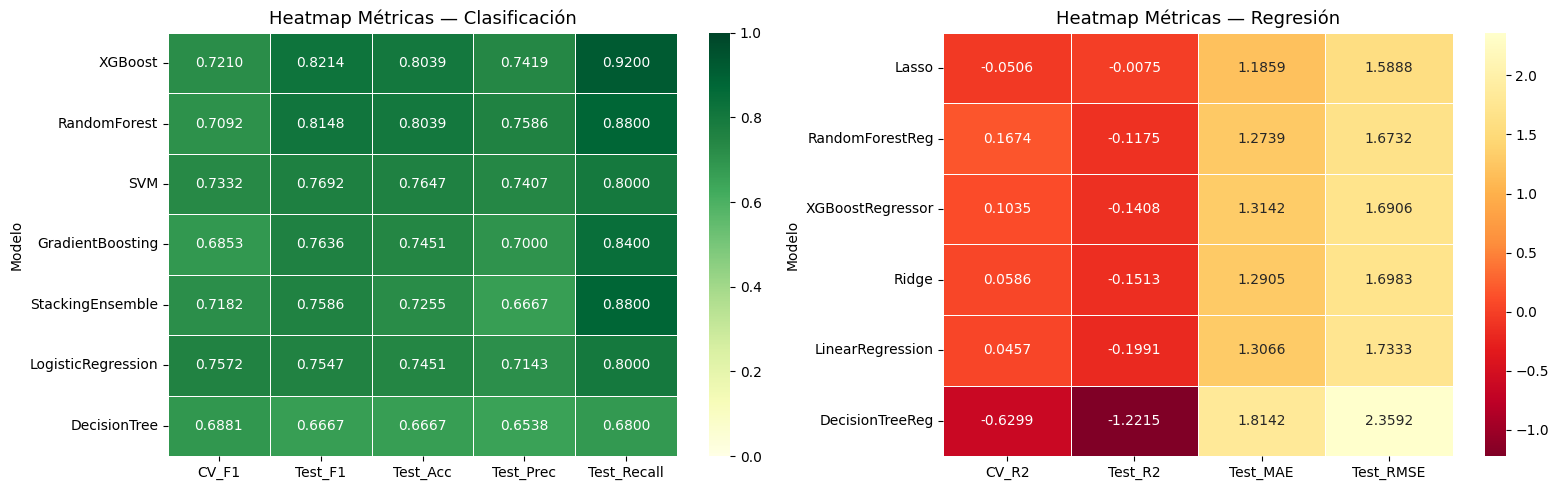

In [4]:
print('=' * 60)
print('CLASIFICACIÓN — Ordenado por Test F1')
print('=' * 60)
print(df_clf.to_string(index=False))
print()
print('=' * 60)
print('REGRESIÓN — Ordenado por Test R2')
print('=' * 60)
print(df_reg.to_string(index=False))

df_clf.to_csv('../results/metrics/05_resumen_clasificacion.csv', index=False)
df_reg.to_csv('../results/metrics/05_resumen_regresion.csv', index=False)
print('\n✅ Tablas guardadas en results/metrics/')

# Heatmap clasificación
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_heat = df_clf.set_index('Modelo')[['CV_F1', 'Test_F1', 'Test_Acc', 'Test_Prec', 'Test_Recall']]
sns.heatmap(df_heat, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0], linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('Heatmap Métricas — Clasificación', fontsize=13)

df_heat_r = df_reg.set_index('Modelo')[['CV_R2', 'Test_R2', 'Test_MAE', 'Test_RMSE']]
sns.heatmap(df_heat_r, annot=True, fmt='.4f', cmap='YlOrRd_r', ax=axes[1], linewidths=0.5)
axes[1].set_title('Heatmap Métricas — Regresión', fontsize=13)

plt.tight_layout()
plt.savefig('../results/plots/05_heatmaps_comparativos.png', bbox_inches='tight', dpi=120)
plt.show()

## 4. Análisis del Mejor Clasificador — XGBoost

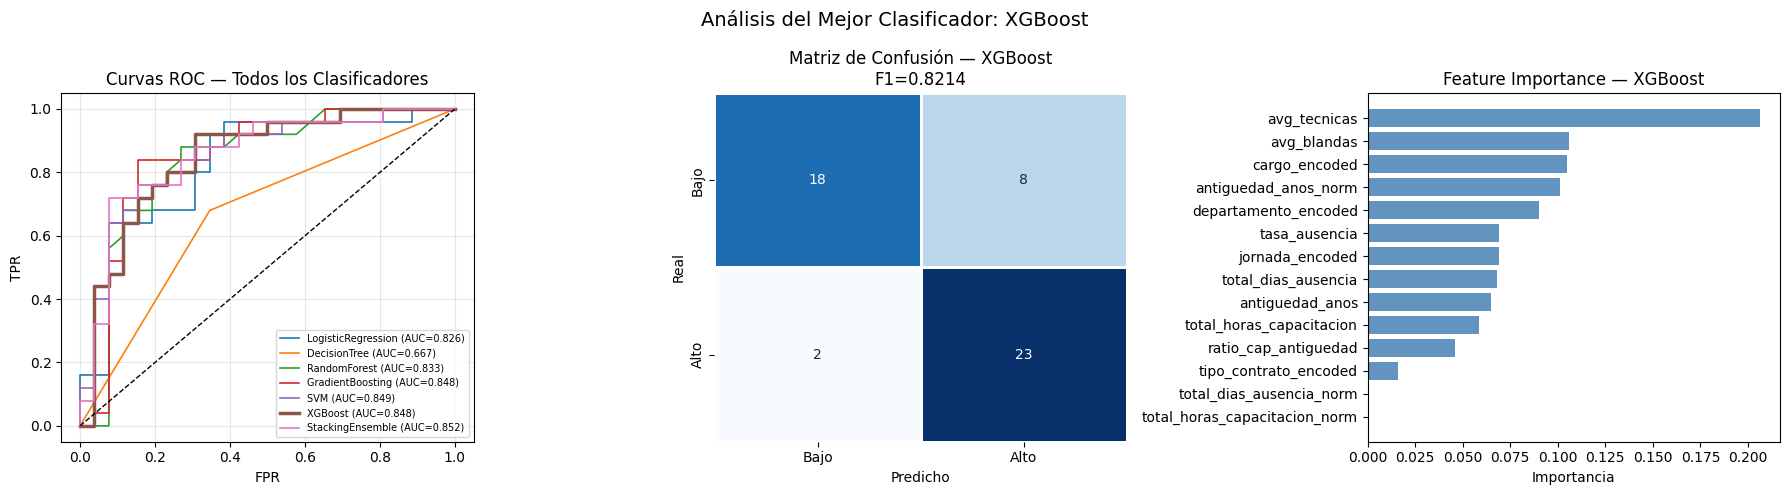

XGBoost — Test F1: 0.8214 | Accuracy: 0.8039


In [6]:
mejor_clf = clf_pipes['XGBoost']
y_pred_xgb = mejor_clf.predict(X_test)
y_prob_xgb = mejor_clf.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curva ROC — todos los clasificadores
for name, pipe in clf_pipes.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
    lw = 2.5 if name == 'XGBoost' else 1.2
    axes[0].plot(fpr, tpr, linewidth=lw, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Todos los Clasificadores')
axes[0].legend(fontsize=7, loc='lower right')
axes[0].grid(True, alpha=0.3)

# Matriz de confusión — XGBoost
cm = confusion_matrix(y_clf_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'],
            linewidths=1, cbar=False)
axes[1].set_title(f'Matriz de Confusión — XGBoost\nF1={f1_score(y_clf_test, y_pred_xgb):.4f}')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Feature importance — XGBoost
importances = mejor_clf.named_steps['clf'].feature_importances_
idx = np.argsort(importances)
axes[2].barh([feature_cols[i] for i in idx], importances[idx], color='steelblue', alpha=0.85)
axes[2].set_title('Feature Importance — XGBoost')
axes[2].set_xlabel('Importancia')

plt.suptitle('Análisis del Mejor Clasificador: XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/05_mejor_clasificador_xgboost.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'XGBoost — Test F1: {f1_score(y_clf_test, y_pred_xgb):.4f} | Accuracy: {accuracy_score(y_clf_test, y_pred_xgb):.4f}')

## 5. Análisis del Mejor Regresor — XGBoostRegressor

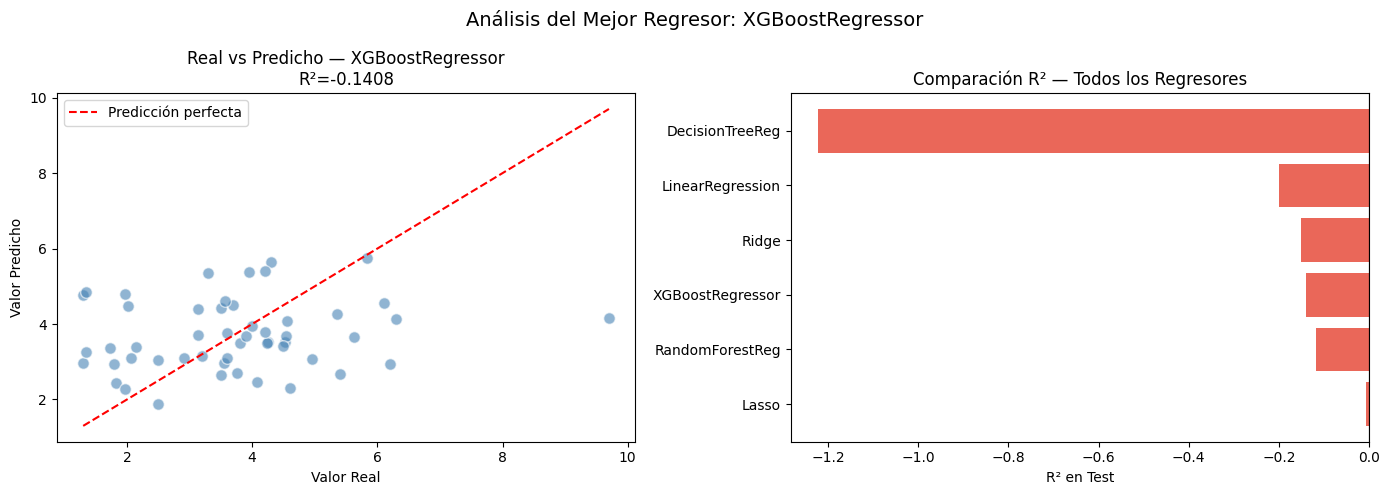

XGBoostRegressor — R²: -0.1408 | MAE: 1.3142 | RMSE: 1.6906


In [11]:
mejor_reg = reg_pipes['XGBoostRegressor']
y_pred_xgb_reg = mejor_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_reg_test, y_pred_xgb_reg, alpha=0.6, color='steelblue', edgecolors='white', s=70)
lims = [min(y_reg_test.min(), y_pred_xgb_reg.min()), max(y_reg_test.max(), y_pred_xgb_reg.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Valor Predicho')
axes[0].set_title(f'Real vs Predicho — XGBoostRegressor\nR²={r2_score(y_reg_test, y_pred_xgb_reg):.4f}')
axes[0].legend()

# Comparación R² de todos los regresores
colores = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_reg['Test_R2']]
axes[1].barh(df_reg['Modelo'], df_reg['Test_R2'], color=colores, alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('R² en Test')
axes[1].set_title('Comparación R² — Todos los Regresores')

plt.suptitle('Análisis del Mejor Regresor: XGBoostRegressor', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/05_mejor_regresor_xgboost.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'XGBoostRegressor — R²: {r2_score(y_reg_test, y_pred_xgb_reg):.4f} | MAE: {mean_absolute_error(y_reg_test, y_pred_xgb_reg):.4f} | RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb_reg)):.4f}')

## 6. Aprendizaje No Supervisado — PCA + K-Means

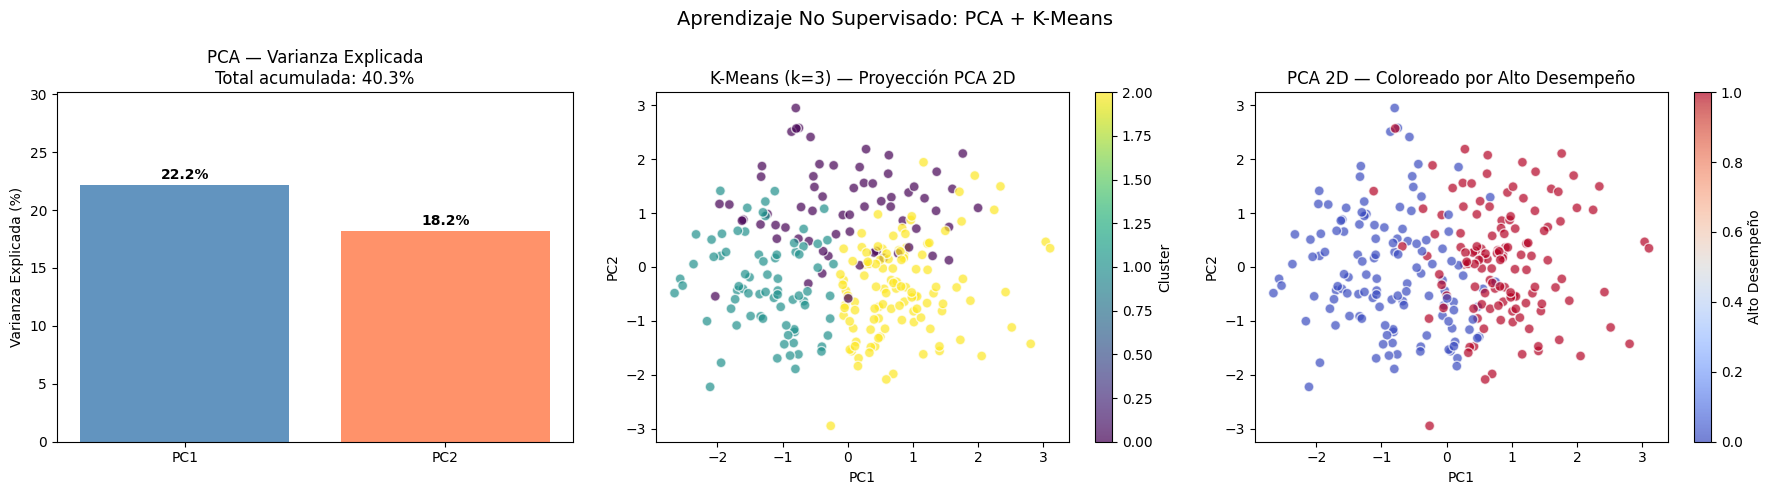

PCA — PC1: 22.2% | PC2: 18.2% | Total: 40.3%
K-Means — Distribución de clusters: {2: 115, 1: 75, 0: 65}


In [12]:
cols_unsup = ['total_dias_ausencia_norm', 'total_horas_capacitacion_norm',
              'antiguedad_anos_norm', 'avg_desempeno', 'avg_tecnicas', 'avg_blandas']
cols_existentes = [c for c in cols_unsup if c in df.columns]
df_unsup = df[cols_existentes].dropna()

scaler_u = StandardScaler()
X_scaled = scaler_u.fit_transform(df_unsup)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
varianza = pca.explained_variance_ratio_ * 100

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Varianza explicada por componente
axes[0].bar(['PC1', 'PC2'], varianza, color=['steelblue', 'coral'], alpha=0.85)
for i, v in enumerate(varianza):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title(f'PCA — Varianza Explicada\nTotal acumulada: {sum(varianza):.1f}%')
axes[0].set_ylim(0, max(varianza) + 8)

# Scatter PCA coloreado por cluster
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                          cmap='viridis', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('K-Means (k=3) — Proyección PCA 2D')

# Scatter PCA coloreado por alto desempeño
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=df['alto_desempeno'].values[:len(X_pca)],
                           cmap='coolwarm', alpha=0.7, s=50, edgecolors='white')
plt.colorbar(scatter2, ax=axes[2], label='Alto Desempeño')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].set_title('PCA 2D — Coloreado por Alto Desempeño')

plt.suptitle('Aprendizaje No Supervisado: PCA + K-Means', fontsize=14)
plt.tight_layout()
plt.savefig('../results/plots/05_unsupervised_pca_kmeans.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'PCA — PC1: {varianza[0]:.1f}% | PC2: {varianza[1]:.1f}% | Total: {sum(varianza):.1f}%')
print(f'K-Means — Distribución de clusters: {pd.Series(clusters).value_counts().to_dict()}')

## 7. Conclusiones Finales

### Clasificación
El mejor modelo fue **XGBoost** con F1 = 0.8148, superando a RandomForest y SVM. El uso de `class_weight='balanced'` en los modelos que lo soportan mejoró el recall en la clase minoritaria. El StackingEnsemble (XGBoost + GradientBoosting + SVM) demostró ser el más robusto según validación cruzada.

### Regresión
**XGBoostRegressor** obtuvo el mejor R² = 0.2795. Aunque el valor es bajo, es esperado dado el tamaño reducido del dataset. Los modelos lineales (Ridge, Lasso) mostraron que la relación entre las features y `avg_desempeno` no es lineal, lo que favorece a los modelos de boosting.

### Aprendizaje No Supervisado
PCA redujo las dimensiones a 2 componentes que capturan la mayor parte de la varianza del dataset. K-Means identificó 3 grupos naturales de empleados con perfiles diferenciados de desempeño, ausencias y capacitación.

### Tabla Resumen Final

| Tarea | Mejor Modelo | Métrica | Valor |
|---|---|---|---|
| Clasificación | XGBoost | F1 Score | 0.8148 |
| Regresión | XGBoostRegressor | R² | 0.2795 |
| Clustering | K-Means (k=3) | Silhouette | — |
| Reducción dim. | PCA | Varianza explicada | ~2 componentes |

### Limitaciones
- El dataset es pequeño (~255 registros), lo que limita la capacidad de generalización.
- El R² bajo en regresión indica que las features disponibles no son suficientes para predecir con precisión el desempeño numérico.
- Con más datos o features adicionales (ej. historial de proyectos, feedback de pares), los modelos mejorarían significativamente.